<a href="https://colab.research.google.com/github/sk27110/ML/blob/HW2/hw_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Машинное обучение

# Домашнее задание 2. Обучение без учителя, кластеризация.

## Общая информация
Дата выдачи: 02.10.2025

Дедлайн: 16.10.2025 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи).

Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.


## О задании

В этом задании мы посмотрим на несколько алгоритмов кластеризации и применим их к текстовым данным. Также мы подробно остановимся на тематическом моделировании текстов, задаче обучения представлений и в каком-то смысле поработаем с semi-supervised learning.

In [88]:
import pandas as pd
import numpy as np

np.random.seed(0xFFFFFFF)
random_state = 42

## Часть 1. Тематическое моделирование текстов

В этой части мы познакомимся с одной из самых популярных задач обучения без учителя &mdash; с задачей тематического моделирования текстов. Допустим, нам доступна некоторая коллекция документов без разметки, и мы хотим автоматически выделить несколько тем, которые встречаются в документах, а также присвоить каждому документу одну (или несколько) тем. Фактически, мы будем решать задачу, похожую на кластеризацию текстов: отличие в том, что нас будет интересовать не только разбиение текстов на группы, но и выделение ключевых слов, определяющих каждую тему.

Мы будем работать с новостными статьями BBC за 2004-2005 годы. Скачайте данные по [ссылке](https://www.kaggle.com/hgultekin/bbcnewsarchive).

In [33]:
data = pd.read_csv('bbc-news-data.csv', sep='\t')
data.sample(5)

,category,filename,title,content
1289,politics,394.txt,Economy focus for election battle,Britain's economic future will be at the hear...
1872,tech,049.txt,Domain system scam fear,A system to make it easier to create website ...
1044,politics,149.txt,Blair returns from peace mission,Prime Minister Tony Blair has arrived back fr...
654,entertainment,145.txt,Sir Paul rocks Super Bowl crowds,Sir Paul McCartney wowed fans with a live min...
134,business,135.txt,Feta cheese battle reaches court,A row over whether only Greece should be allo...


Как вы могли заметить, данные уже содержат разметку по тематике (колонка category). В этой части мы забудем, что она есть, и будем работать только с текстовыми данными. Проведем предобработку текста, состоящую из следующих пунктов:

* Объединим заголовок и содержание статьи в одно поле.
* Приведем текст к нижнему регистру, разобьем его на токены.
* Оставим только буквенные слова (удалив, таким образом, пунктуацию и числа).
* Применим лемматизацию.
* Удалим стоп-слова.


In [34]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [35]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

stop_words = set(stopwords.words('english') + ['ha', 'wa', 'say', 'said'])
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
def preprocess(text):
    text = list(filter(str.isalpha, word_tokenize(text.lower())))
    text = list(lemmatizer.lemmatize(word) for word in text)
    text = list(word for word in text if word not in stop_words)
    return ' '.join(text)

In [37]:
data['raw_text'] = data.apply(lambda row: row.title + row.content, axis=1)
data['text'] = data.apply(lambda row: preprocess(row.raw_text), axis=1)

Для визуализации частот слов в текстах мы будем использовать [облака тегов](https://en.wikipedia.org/wiki/Tag_cloud).

In [38]:
from wordcloud import WordCloud

def draw_wordcloud(texts, max_words=1000, width=1000, height=500):
    wordcloud = WordCloud(background_color='white', max_words=max_words,
                          width=width, height=height)

    joint_texts = ' '.join(list(texts))
    wordcloud.generate(joint_texts)
    return wordcloud.to_image()

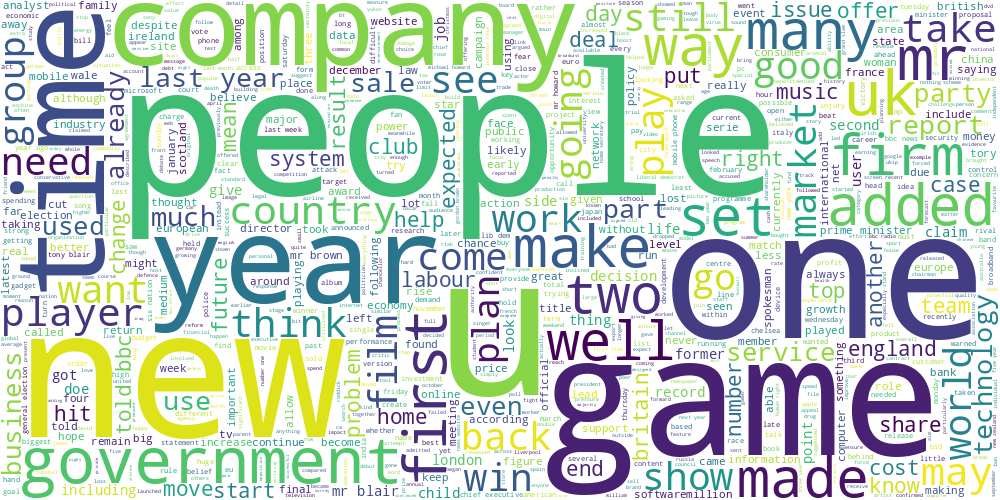

In [39]:
draw_wordcloud(data.text)

**Задание 1.1 (1 балл).** Обучите алгоритм K-Means на tf-idf представлениях текстов. При обучении tf-idf векторайзера рекомендуется отбрасывать редко встречающиеся слова, а также воздержитесь от использования N-грамм. Возьмите не очень большое число кластеров, чтобы было удобно интерпретировать получившиеся темы (например, `n_clusters` = 8). Постройте облака тегов для текстов из разных кластеров. Получились ли темы интерпретируемыми? Попробуйте озаглавить каждую тему.

**Ответ:**
Заголовки тем примерно такие:

0) IT
1) Бизнес
2) Политика/мир
3) Экономика
4) Футбол
5) Спорт (?)
6) Внутренняя политика
7) Кинематогроф

In [40]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=5,
    stop_words=list(stop_words),
    ngram_range=(1, 1)
)

In [41]:
X = vectorizer.fit_transform(data["text"])

In [42]:
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(X)

KMeans()

In [43]:
data['cluster_kmeans'] = kmeans.labels_

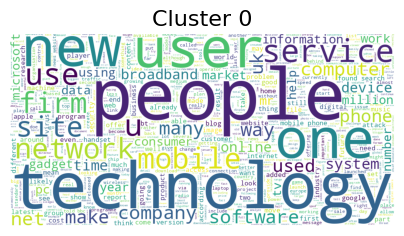

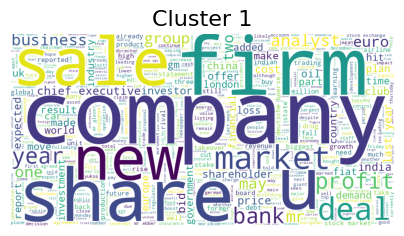

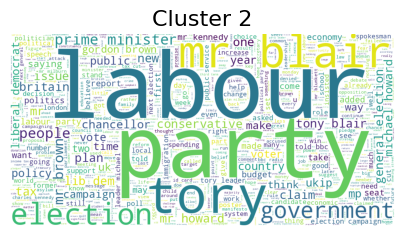

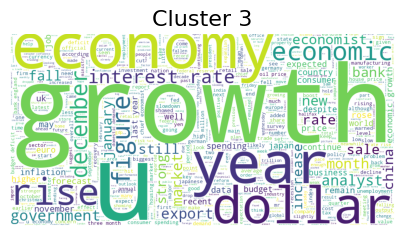

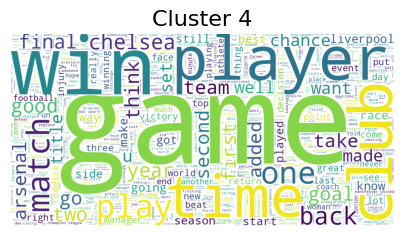

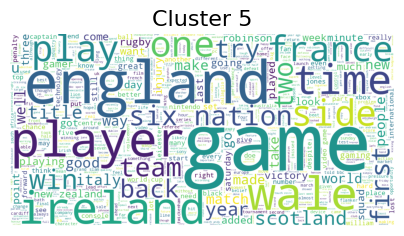

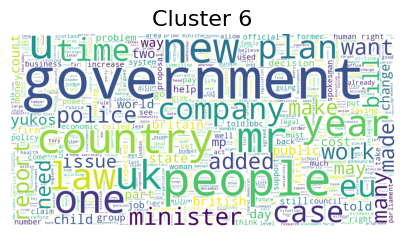

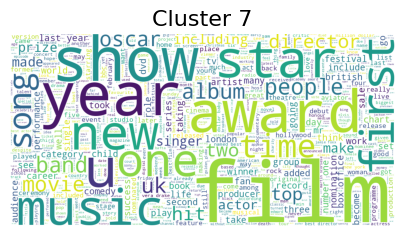

In [44]:
import matplotlib.pyplot as plt


for cluster_id in range(n_clusters):
    plt.figure(figsize=(5, 2.5))
    plt.imshow(draw_wordcloud(data[data['cluster_kmeans'] == cluster_id]["text"]))
    plt.axis("off")
    plt.title(f"Cluster {cluster_id}", fontsize=16)
    plt.show()

**Задание 1.2 (1 балл).** Попробуем другой способ выделить ключевые слова для каждой темы. Помимо непосредственного разбиения объектов алгоритм K-Means получает центр каждого кластера. Попробуйте взять центры кластеров и посмотреть на слова, для которых значения соответствующих им признаков максимальны. Согласуются ли полученные слова с облаками тегов из прошлого задания?

**Ответ:**
Да, полученные слова согласуются с облаками тегов.

In [46]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(n_clusters):
    top_terms = [terms[ind] for ind in order_centroids[i, :5]]
    print(f"Кластер {i}: {', '.join(top_terms)}")

Кластер 0: mobile, phone, people, technology, user
Кластер 1: company, share, firm, profit, sale
Кластер 2: mr, labour, election, party, blair
Кластер 3: economy, growth, rate, economic, figure
Кластер 4: champion, club, game, chelsea, win
Кластер 5: game, england, wale, ireland, rugby
Кластер 6: mr, government, would, lord, law
Кластер 7: film, award, best, show, star


**Задание 1.3 (2 балла).** Посмотрим на кластеризацию для текстовых данных (в качестве признакого описания снова используем tf-idf). Получите три разбиения на кластеры с помощью алгоритмов K-Means, DBSCAN и спектральной кластеризации (на этот раз воспользуйтесь реализацией из `sklearn`). Для K-Means и спектральной кластеризации возьмите одинаковое небольшое число кластеров, подберите параметр `eps` метода DBSCAN так, чтобы получить приблизительно такое же число кластеров.

Далее, обучите двухмерные t-SNE представления над tf-idf признаками текстов. Визуализируйте эти представления для каждого алгоритма, раскрасив каждый кластер своим цветом. Лучше всего расположить визуализации на одном графике на трех разных сабплотах. Не забудьте, что DBSCAN помечает некоторые точки как шумовые (можно раскрасить их в отдельный цвет).

In [47]:
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

n_classes = 8

kmeans = KMeans(n_clusters=n_classes)
spectral = SpectralClustering(n_clusters=n_classes)

kmeans.fit(X)
spectral.fit(X)

data['cluster_kmeans'] = kmeans.labels_
data['cluster_spectral'] = spectral.labels_

In [49]:
dbscan = DBSCAN(eps=0.83)
dbscan.fit(X)
data['cluster_dbscan'] = dbscan.labels_
np.unique(dbscan.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7])

In [50]:
data[data['cluster_dbscan'] == -1].shape[0]

2171

Очень много точек отмечается как шумовые

In [51]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_tsne = tsne.fit_transform(X.toarray())


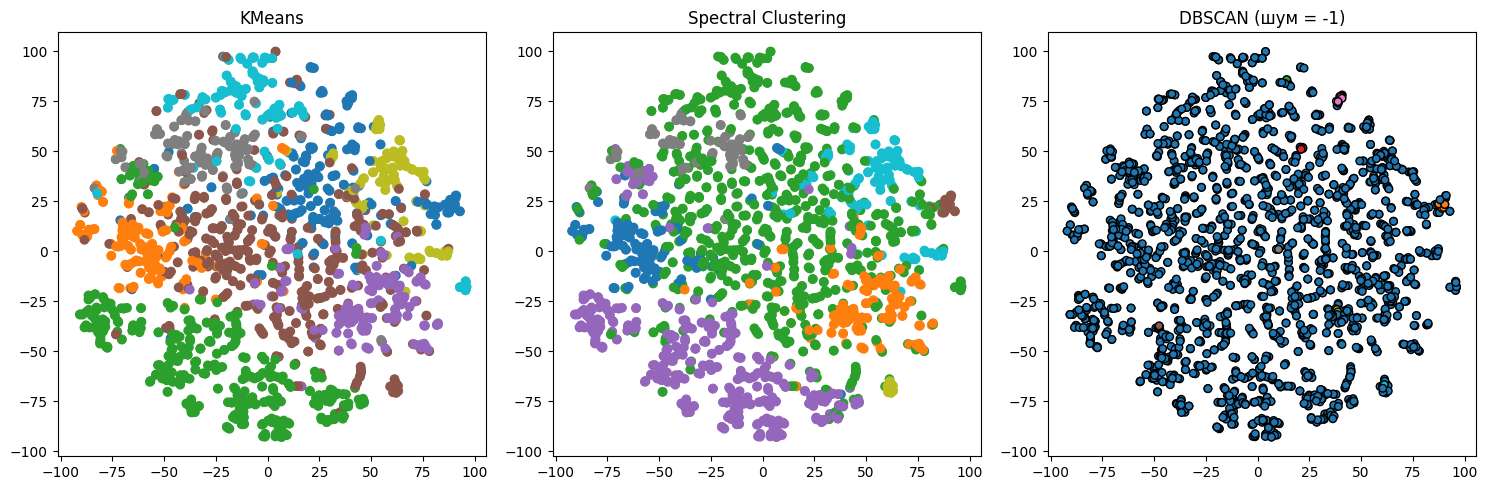

In [52]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=data["cluster_kmeans"], cmap='tab10')
axes[0].set_title("KMeans")


axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=data["cluster_spectral"], cmap='tab10')
axes[1].set_title("Spectral Clustering")


colors = np.array(data["cluster_dbscan"])
axes[2].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=np.where(colors == -1, -1, colors),
    cmap='tab10',
    s=30,
    edgecolors='k'
)
axes[2].set_title("DBSCAN (шум = -1)")

plt.tight_layout()
plt.show()

Прокомментируйте получившиеся результаты. Какой баланс кластеров получился у разных методов? Соотносятся ли визуализации для текстов с визуализациями для географических данных?

**Ответ:**
У kmeans и spectral clustering довольно схожие результаты. По картинке можно сказать, что одни кластеры сильно больше других, но тем не менее, все классы различимы. DBSCAN же почти все данные помечает как шумовые.

**Задание 1.4 (2 балла).** Обучите модель латентного размещения Дирихле. Не забудьте, что она работает с мешком слов, а не с tf-idf признаками. Придумайте, как превратить распределение тем для текста в номер его кластера. Возьмите параметр `n_components` в 2-3 раза больше, чем число кластеров для K-Means. Получились ли темы более узкими от такого нововведения? Постройте облака тегов для нескольких наиболее удачных тем.

**Ответ:**
Появились некторые узкие темы(например, музыка). Но кажется, что некоторые темы повторяются или очень схожи (то есть на самом деле принадлежат к одной общей теме, но были разбиты на разные из-за большого числа кластеров).

In [53]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

count_vectorizer = CountVectorizer(
    max_df=0.8,
    min_df=5,
    stop_words='english',
    ngram_range=(1, 1)
)

X = count_vectorizer.fit_transform(data["text"])
LDA = LatentDirichletAllocation(n_components=n_clusters * 3, random_state=42)
LDA.fit(X)


LatentDirichletAllocation(n_components=24, random_state=42)

In [54]:
topic_distributions = LDA.transform(X)

In [55]:
data["cluster_lda"] = topic_distributions.argmax(axis=1)

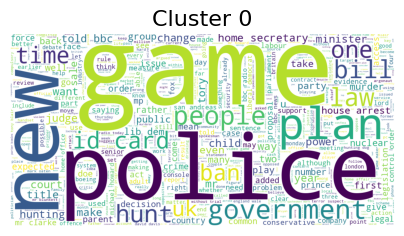

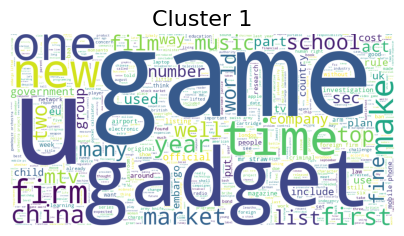

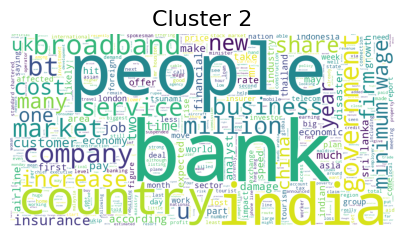

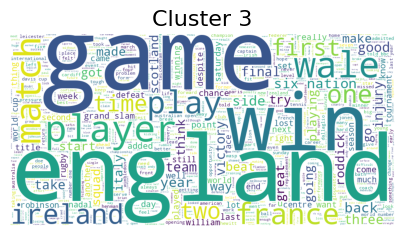

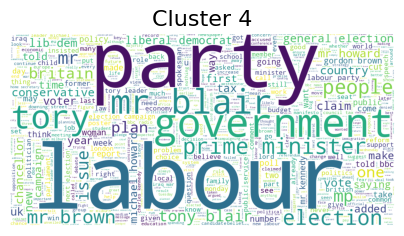

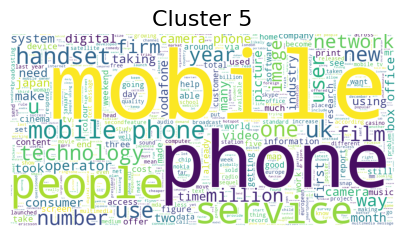

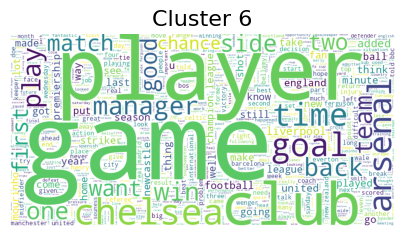

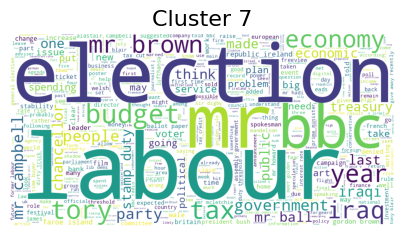

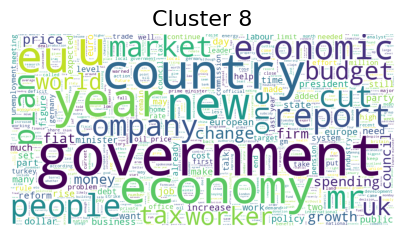

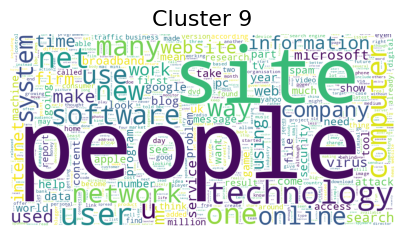

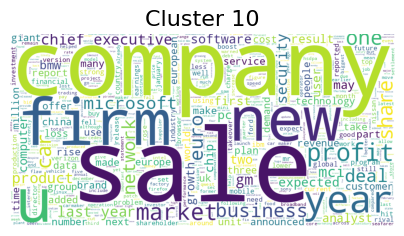

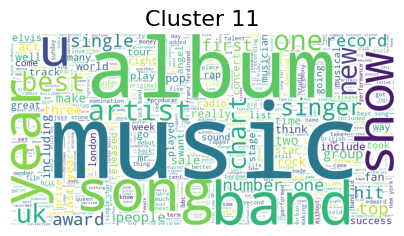

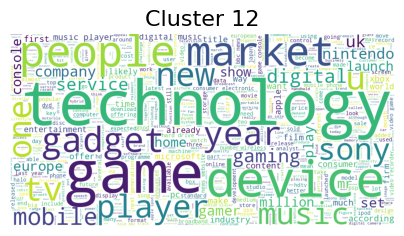

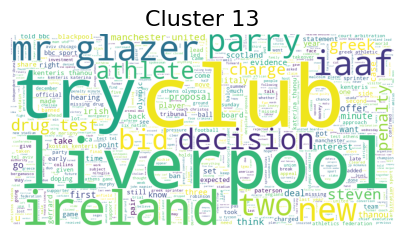

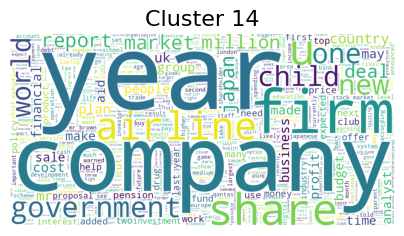

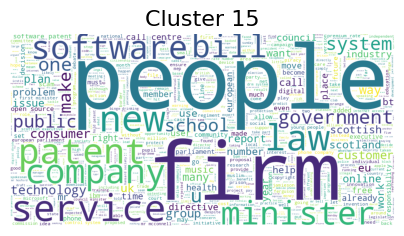

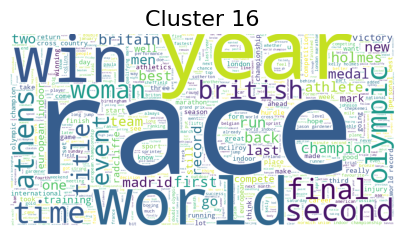

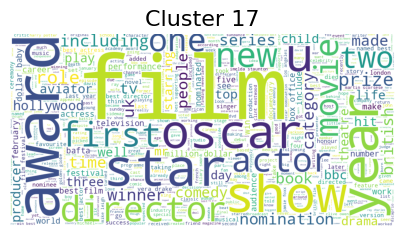

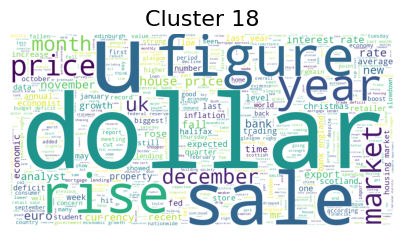

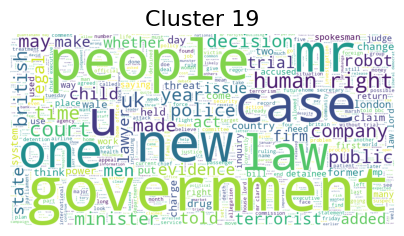

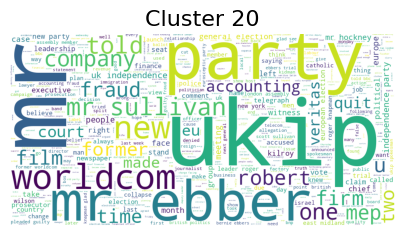

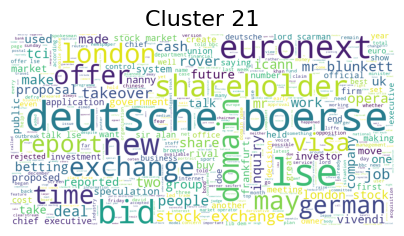

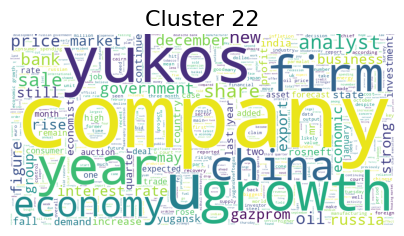

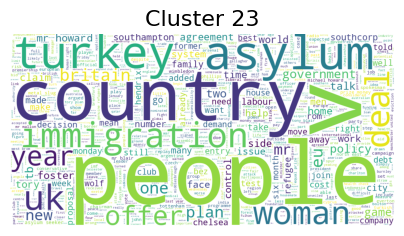

In [56]:
for cluster_id in range(n_clusters*3):
    plt.figure(figsize=(5, 2.5))
    plt.imshow(draw_wordcloud(data[data['cluster_lda'] == cluster_id]["text"]))
    plt.axis("off")
    plt.title(f"Cluster {cluster_id}", fontsize=16)
    plt.show()

## Часть 2. Transfer learning для задачи классификации текстов

**Задание 2.1 (0.5 балла).** Вспомним, что у нас есть разметка для тематик статей. Попробуем обучить классификатор поверх unsupervised-представлений для текстов. Рассмотрите три модели:

* Логистическая регрессия на tf-idf признаках
* K-Means на tf-idf признаках + логистическая регрессия на расстояниях до центров кластеров
* Латентное размещение Дирихле + логистическая регрессия на вероятностях тем

Разделите выборку на обучающую и тестовую, замерьте accuracy на обоих выборках для всех трех моделей. Параметры всех моделей возьмите равными значениям по умолчанию.

In [64]:
data = pd.read_csv('bbc-news-data.csv', sep='\t')

In [65]:
data['raw_text'] = data.apply(lambda row: row.title + row.content, axis=1)
data['text'] = data.apply(lambda row: preprocess(row.raw_text), axis=1)

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data["class"] = encoder.fit_transform(data["category"])

X = data["content"]
y = data["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = random_state)

In [90]:
vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=5,
    stop_words=list(stop_words),
    ngram_range=(1, 1)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Логиститческая регрессия:

In [93]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=random_state)
lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)
print("accuracy log_reg:", accuracy_score(y_test, y_pred))

accuracy log_reg: 0.9730337078651685


KMeans + Логистическая регрессия

In [105]:
from sklearn.cluster import KMeans

n_clusters = 8

kmeans = KMeans(n_clusters = n_clusters, random_state=random_state)

kmeans.fit(X_train_tfidf)

def kmeans_features(model, X):
    return model.transform(X)

X_train_kmeans = kmeans_features(kmeans, X_train_tfidf)
X_test_kmeans = kmeans_features(kmeans, X_test_tfidf)

lr = LogisticRegression(random_state = random_state)
lr.fit(X_train_kmeans, y_train)
y_pred = lr.predict(X_test_kmeans)
print("accuracy kmeans + logreg:", accuracy_score(y_pred, y_test))

accuracy kmeans + logreg: 0.8224719101123595


LDA + Логистическая регрессия:

In [106]:
count_vectorizer = CountVectorizer(
    max_df=0.8,
    min_df=5,
    stop_words=list(stop_words),
    ngram_range=(1, 1)
)

X_train_cnt = count_vectorizer.fit_transform(X_train)
X_test_cnt = count_vectorizer.transform(X_test)

LDA = LatentDirichletAllocation(n_components=n_clusters, random_state=42)
LDA.fit(X_train_cnt)

lr = LogisticRegression(random_state = random_state)
lr.fit(LDA.transform(X_train_cnt), y_train)
y_pred = lr.predict(LDA.transform(X_test_cnt))
print("accuracy lda + logreg:", accuracy_score(y_pred, y_test))

accuracy lda + logreg: 0.9191011235955057


У какой модели получилось лучшее качество? С чем это связано?

**Ответ:**
Результаты: \
logreg: 0.97\
kmeans + logreg: 0.82\
lda + logreg: 0.91

Почему так происходит:

1) LogReg работает почти с исходными данными, которые не сжимаются

2) KMeans же сперва сжимает данные, превращая их в расстояния до центров кластеров. Тем самым, часть информации теряется. Так же не понятно, насколько хорошо работает сам kmeans и насколько хорошо он определяет кластеры. Поэтому ошибка довольно большая

3) LDA тоже сжимает данные, но, видимо, для логистической регрессии вероятности классов более хороший признак, чем расстояния до центров кластеров.


**Задание 2.2 (1.5 балла).** Теперь просимулируем ситуацию слабой разметки, которая часто встречается в реальных данных. Разделим обучающую выборку в пропорции 5:65:30. Будем называть части, соответственно, размеченный трейн, неразмеченный трейн и валидация.

Все unsupervised-алгоритмы (векторайзеры и алгоритмы кластеризации) запускайте на всем трейне целиком (размеченном и неразмеченном, суммарно 70%), а итоговый классификатор обучайте только на размеченном трейне (5%). Подберите гиперпараметры моделей по качеству на валидации (30%), а затем оцените качество на тестовой выборке (которая осталась от прошлого задания). Не скромничайте при подборе числа кластеров, сейчас нас интересует не интерпретируемое разбиение выборки, а итоговое качество классификации.

In [169]:
X_train_cur, X_val, y_train_cur, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=random_state, stratify=y_train
)


vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=5,
    stop_words=list(stop_words),
    ngram_range=(1,1)
)
X_train_cur_tfidf = vectorizer.fit_transform(X_train_cur)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)


count_vectorizer = CountVectorizer(
    max_df=0.8,
    min_df=5,
    stop_words=list(stop_words),
    ngram_range=(1,1)
)
X_train_cur_cnt = count_vectorizer.fit_transform(X_train_cur)
X_val_cnt = count_vectorizer.transform(X_val)
X_test_cnt = count_vectorizer.transform(X_test)


idx_marked, idx_not_marked = train_test_split(
    np.arange(X_train_cur_tfidf.shape[0]), test_size=0.92, random_state=random_state
)

X_train_marked_tfidf = X_train_cur_tfidf[idx_marked]
X_train_not_marked_tfidf = X_train_cur_tfidf[idx_not_marked]

X_train_marked_cnt = X_train_cur_cnt[idx_marked]
X_train_not_marked_cnt = X_train_cur_cnt[idx_not_marked]

y_train_marked = y_train_cur.iloc[idx_marked]
y_train_not_marked = y_train_cur.iloc[idx_not_marked]

In [153]:
import numpy as np

cluster_options = list(range(2, 1001, 50))

KMeans + Логистическая регрессия:

In [157]:
best_score_kmeans = 0
best_kmeans = None
best_lr_kmeans = None
best_n_clusters = None

for n_c in cluster_options:
    kmeans = KMeans(n_clusters=n_c, random_state=random_state)
    kmeans.fit(X_train_cur_tfidf)

    X_marked_feats = kmeans.transform(X_train_marked_tfidf)
    X_val_feats = kmeans.transform(X_val_tfidf)

    lr = LogisticRegression(random_state=random_state, max_iter=1000)
    lr.fit(X_marked_feats, y_train_marked)

    y_val_pred = lr.predict(X_val_feats)
    score = accuracy_score(y_val, y_val_pred)

    print(f"n_clusters={n_c}, val_accuracy={score:.4f}")

    if score > best_score_kmeans:
        best_score_kmeans = score
        best_kmeans = kmeans
        best_lr_kmeans = lr
        best_n_clusters = n_c

print(f"K-Means: лучший n_clusters={best_n_clusters}, val_accuracy={best_score_kmeans:.4f}")


X_test_kmeans = best_kmeans.transform(X_test_tfidf)
y_test_pred = best_lr_kmeans.predict(X_test_kmeans)
print("K-Means + Logistic Regression accuracy на тесте:", accuracy_score(y_test, y_test_pred))


n_clusters=2, val_accuracy=0.2472
n_clusters=52, val_accuracy=0.7622
n_clusters=102, val_accuracy=0.7959
n_clusters=152, val_accuracy=0.8277
n_clusters=202, val_accuracy=0.8446
n_clusters=252, val_accuracy=0.8652
n_clusters=302, val_accuracy=0.8745
n_clusters=352, val_accuracy=0.8801
n_clusters=402, val_accuracy=0.8895
n_clusters=452, val_accuracy=0.8933
n_clusters=502, val_accuracy=0.8989
n_clusters=552, val_accuracy=0.8989
n_clusters=602, val_accuracy=0.9026
n_clusters=652, val_accuracy=0.9101
n_clusters=702, val_accuracy=0.9064
n_clusters=752, val_accuracy=0.9101
n_clusters=802, val_accuracy=0.8989
n_clusters=852, val_accuracy=0.9045
n_clusters=902, val_accuracy=0.9176
n_clusters=952, val_accuracy=0.9157
K-Means: лучший n_clusters=902, val_accuracy=0.9176
K-Means + Logistic Regression accuracy на тесте: 0.903370786516854


In [161]:
cluster_options = list(range(2, 20, 1))

In [162]:
best_score_lda = 0
best_n_topics = None
best_lda = None
best_lr_lda = None

for n_c in cluster_options:
    lda = LatentDirichletAllocation(n_components=n_c, random_state=random_state)
    lda.fit(X_train_cur_cnt)

    X_train_topics = lda.transform(X_train_marked_cnt)
    X_val_topics = lda.transform(X_val_cnt)

    lr = LogisticRegression(random_state=random_state, max_iter=1000)
    lr.fit(X_train_topics, y_train_marked)

    y_val_pred = lr.predict(X_val_topics)
    score = accuracy_score(y_val, y_val_pred)

    print(f"n_clusters={n_c}, val_accuracy={score:.4f}")

    if score > best_score_lda:
        best_score_lda = score
        best_lda = lda
        best_lr_lda = lr
        best_n_topics = n_c

print(f"LDA: лучший n_topics={best_n_topics}, val_accuracy={best_score_lda:.4f}")


X_test_topics = best_lda.transform(X_test_cnt)
y_test_pred_lda = best_lr_lda.predict(X_test_topics)
print("LDA + Logistic Regression accuracy на тесте:", accuracy_score(y_test, y_test_pred_lda))

n_clusters=2, val_accuracy=0.4700
n_clusters=3, val_accuracy=0.5955
n_clusters=4, val_accuracy=0.6779
n_clusters=5, val_accuracy=0.8371
n_clusters=6, val_accuracy=0.7715
n_clusters=7, val_accuracy=0.8876
n_clusters=8, val_accuracy=0.9064
n_clusters=9, val_accuracy=0.8820
n_clusters=10, val_accuracy=0.9082
n_clusters=11, val_accuracy=0.9045
n_clusters=12, val_accuracy=0.8858
n_clusters=13, val_accuracy=0.9139
n_clusters=14, val_accuracy=0.9064
n_clusters=15, val_accuracy=0.8820
n_clusters=16, val_accuracy=0.8858
n_clusters=17, val_accuracy=0.8839
n_clusters=18, val_accuracy=0.8914
n_clusters=19, val_accuracy=0.8858
LDA: лучший n_topics=13, val_accuracy=0.9139
LDA + Logistic Regression accuracy на тесте: 0.9235955056179775


Как изменились результаты по сравнению с обучением на полной разметке? Сделайте выводы.

**Ответ:**

Как мы видим, результаты с учетом подбора гиперпараметров стали сильно лучше, чем результаты на полной выборке, но без подбора гиперпараметров. Как будто сравнивать их не очень честно.

Но, можно сделать вывод, что такой метод обучения алгоритма хорошо работает при отсутвии меток на большой части обучающей выборки.

**Задание 3 (1 балл)**. Разберитесь с semi-supervised методами, которые реализованы в `sklearn` и примените их к заданию 3.2. Получилось ли добиться лучшего качества? Сделайте выводы.

In [179]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np


y_all = np.full(len(y_train_cur), -1, dtype=int)
y_all[idx_marked] = y_train_marked.values

threshold_values = np.arange(0.1, 1.0, 0.05)
best_model = None
best_score = 0
best_threshold = None

for thr in threshold_values:
    base_clf = LogisticRegression(max_iter=1000, random_state=random_state)
    self_tr = SelfTrainingClassifier(base_clf, threshold=thr, criterion='threshold', verbose=False)

    self_tr.fit(X_train_cur_tfidf, y_all)

    y_val_pred = self_tr.predict(X_val_tfidf)
    score = accuracy_score(y_val, y_val_pred)
    print(f"threshold={thr}, val_accuracy={score:.4f}")

    if score > best_score:
        best_score = score
        best_threshold = thr
        best_model = self_tr

print(f"\n Лучший threshold = {best_threshold}, val accuracy = {best_score:.4f}")

y_test_pred_self = best_model.predict(X_test_tfidf)
test_acc_self = accuracy_score(y_test, y_test_pred_self)
print(f"test acc: {test_acc_self:.4f}")


threshold=0.1, val_accuracy=0.7921
threshold=0.15000000000000002, val_accuracy=0.7921
threshold=0.20000000000000004, val_accuracy=0.7921
threshold=0.25000000000000006, val_accuracy=0.8090
threshold=0.30000000000000004, val_accuracy=0.7697
threshold=0.3500000000000001, val_accuracy=0.6404
threshold=0.40000000000000013, val_accuracy=0.5206
threshold=0.45000000000000007, val_accuracy=0.3577
threshold=0.5000000000000001, val_accuracy=0.2004
threshold=0.5500000000000002, val_accuracy=0.1910
threshold=0.6000000000000002, val_accuracy=0.7903
threshold=0.6500000000000001, val_accuracy=0.7903
threshold=0.7000000000000002, val_accuracy=0.7903
threshold=0.7500000000000002, val_accuracy=0.7903
threshold=0.8000000000000002, val_accuracy=0.7903
threshold=0.8500000000000002, val_accuracy=0.7903
threshold=0.9000000000000002, val_accuracy=0.7903
threshold=0.9500000000000003, val_accuracy=0.7903

 Лучший threshold = 0.25000000000000006, val accuracy = 0.8090
test acc: 0.7933


In [183]:
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import normalize
import numpy as np


y_all = np.full(len(y_train_cur), -1, dtype=int)
y_all[idx_marked] = y_train_marked.values


X_train_cur_norm = normalize(X_train_cur_tfidf)
X_val_norm = normalize(X_val_tfidf)
X_test_norm = normalize(X_test_tfidf)


kernel_options = ['knn', 'rbf']
n_neighbors_options = [5, 10, 15]
alpha_options = [0.1, 0.2, 0.5]

best_model = None
best_val_acc = 0
best_params = {}


for kernel in kernel_options:
    for n_neighbors in n_neighbors_options:
        for alpha in alpha_options:
            model = LabelSpreading(kernel=kernel, n_neighbors=n_neighbors, alpha=alpha, max_iter=1000)
            model.fit(X_train_cur_norm, y_all)

            y_val_pred = model.predict(X_val_norm)
            val_acc = accuracy_score(y_val, y_val_pred)

            print(f"kernel={kernel}, n_neighbors={n_neighbors}, alpha={alpha:.2f}, val_acc={val_acc:.4f}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_params = {'kernel': kernel, 'n_neighbors': n_neighbors, 'alpha': alpha}


print("\n Лучшие параметры:", best_params)
print(f"Validation accuracy: {best_val_acc:.4f}")

y_test_pred = best_model.predict(X_test_norm)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy: {test_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


kernel=knn, n_neighbors=5, alpha=0.10, val_acc=0.8502
kernel=knn, n_neighbors=5, alpha=0.20, val_acc=0.8539


/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


kernel=knn, n_neighbors=5, alpha=0.50, val_acc=0.8521
kernel=knn, n_neighbors=10, alpha=0.10, val_acc=0.8764
kernel=knn, n_neighbors=10, alpha=0.20, val_acc=0.8783
kernel=knn, n_neighbors=10, alpha=0.50, val_acc=0.8858
kernel=knn, n_neighbors=15, alpha=0.10, val_acc=0.9139
kernel=knn, n_neighbors=15, alpha=0.20, val_acc=0.9157
kernel=knn, n_neighbors=15, alpha=0.50, val_acc=0.9213
kernel=rbf, n_neighbors=5, alpha=0.10, val_acc=0.8464
kernel=rbf, n_neighbors=5, alpha=0.20, val_acc=0.8464
kernel=rbf, n_neighbors=5, alpha=0.50, val_acc=0.8633
kernel=rbf, n_neighbors=10, alpha=0.10, val_acc=0.8464
kernel=rbf, n_neighbors=10, alpha=0.20, val_acc=0.8464
kernel=rbf, n_neighbors=10, alpha=0.50, val_acc=0.8633
kernel=rbf, n_neighbors=15, alpha=0.10, val_acc=0.8464
kernel=rbf, n_neighbors=15, alpha=0.20, val_acc=0.8464
kernel=rbf, n_neighbors=15, alpha=0.50, val_acc=0.8633

 Лучшие параметры: {'kernel': 'knn', 'n_neighbors': 15, 'alpha': 0.5}
Validation accuracy: 0.9213
Test accuracy: 0.9079


Нет, добиться лучших результатов не вышло.

**Задание 4 (1 балл)**. Есть такая метрика [BCubed](https://www.researchgate.net/profile/Julio-Gonzalo-2/publication/225548032_Amigo_E_Gonzalo_J_Artiles_J_et_alA_comparison_of_extrinsic_clustering_evaluation_metrics_based_on_formal_constraints_Inform_Retriev_12461-486/links/0c96052138dbb99740000000/Amigo-E-Gonzalo-J-Artiles-J-et-alA-comparison-of-extrinsic-clustering-evaluation-metrics-based-on-formal-constraints-Inform-Retriev-12461-486.pdf) хорошо подходит для сравнения алгоритмов кластеризации, если нам известно настоящее разделение на кластеры (gold standard). Реализуйте подсчет метрики BCubed и сравните несколько алгоритмов кластеризации на текстовых данных из основного задания. В качестве gold standard используйте разметку category.

In [ ]:
# YOUR CODE HERE ‿︵‿︵ヽ(°□° )ノ︵‿︵‿